In [1]:
import os
import sys
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.lib
import pyarrow.parquet as pq
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import dacos.research as dc

matplotlib.use("Agg")  #

In [86]:
notebook_dir = Path.cwd()
project_root = (
    notebook_dir.parent.parent
)  # naik dua level: research/notebook -> research -> orca
SILVER_LAKE_PATH = project_root / "data" / "silver"

print(f"📁 Notebook directory: {notebook_dir}")
print(f"📁 Project root: {project_root}")
print(f"📁 Silver Lake path: {SILVER_LAKE_PATH}")

# Verifikasi keberadaan folder
if not SILVER_LAKE_PATH.exists():
    raise FileNotFoundError(f"❌ Folder {SILVER_LAKE_PATH} tidak ditemukan.")

📁 Notebook directory: /home/bumip/orca/research/notebook
📁 Project root: /home/bumip/orca
📁 Silver Lake path: /home/bumip/orca/data/silver


In [87]:
parquet_files = sorted(SILVER_LAKE_PATH.glob("**/*.parquet"))
print(f"📄 Ditemukan {len(parquet_files)} file .parquet di dalam {SILVER_LAKE_PATH}")

if not parquet_files:
    raise FileNotFoundError(
        f"❌ Tidak ada file .parquet di {SILVER_LAKE_PATH} atau subfoldernya."
    )

📄 Ditemukan 39 file .parquet di dalam /home/bumip/orca/data/silver


In [88]:
for i, f in enumerate(parquet_files[:5]):
    print(f"    {i+1}, {f.relative_to(project_root)}")
if len(parquet_files) > 5:
    print("    ...")

    1, data/silver/year=2023/month=01/00000000.parquet
    2, data/silver/year=2023/month=02/00000000.parquet
    3, data/silver/year=2023/month=03/00000000.parquet
    4, data/silver/year=2023/month=04/00000000.parquet
    5, data/silver/year=2023/month=05/00000000.parquet
    ...


In [89]:
def extract_symbols_from_schema(file_path: Path) -> Set[str]:
    """
    Baca schema parquet dan ekstrak simbol dari kolom spread_* atau z_score_*.

    Args:
        file_path: Path ke file parquet.

    Returns:
        Set berisi simbol-simbol unik yang ditemukan dalam file tersebut.
    """
    try:
        schema = pq.read_schema(file_path)
    except Exception as e:
        raise RuntimeError(f"Gagal membaca schema {file_path}: {e}")

    symbols = set()
    for field in schema.names:
        # Cari kolom dengan pola spread_XXXX atau z_score_XXXX
        if field.startswith("spread_"):
            symbol = field.replace("spread_", "")
            symbols.add(symbol)
        elif field.startswith("z_score_"):
            symbol = field.replace("z_score_", "")
            symbols.add(symbol)
    return symbols

In [90]:
all_symbols: Set[str] = set()
file_count = 0
error_files = []

for file in parquet_files:
    try:
        symbols_in_file = extract_symbols_from_schema(file)
        all_symbols.update(symbols_in_file)
        file_count += 1
    except Exception as e:
        error_files.append((str(file), str(e)))
        print(f"⚠️  Gagal memproses {file.name}: {e}")
        continue

print(f"\n✅ Berhasil memproses {file_count} dari {len(parquet_files)} file.")
if error_files:
    print(f"⚠️  {len(error_files)} file gagal diproses.")


✅ Berhasil memproses 39 dari 39 file.


In [91]:
# %% [markdown]
# # Re-build AVAILABLE_SYMBOLS dengan Membaca Semua File Parquet
#
# Untuk memastikan kita mendapatkan semua simbol yang benar-benar ada di data, kita akan membaca schema dari semua file, bukan hanya 10 file pertama. Ini akan menghindari simbol yang mungkin tidak muncul di file sampel.

from pathlib import Path

# %%
import pyarrow.parquet as pq

# Pastikan SILVER_LAKE_PATH sudah didefinisikan
if "SILVER_LAKE_PATH" not in locals():
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent.parent
    SILVER_LAKE_PATH = project_root / "data" / "silver"
    print(f"📁 Silver Lake path: {SILVER_LAKE_PATH}")

# Kumpulkan semua file parquet
parquet_files = sorted(SILVER_LAKE_PATH.glob("**/*.parquet"))
print(f"📄 Ditemukan {len(parquet_files)} file .parquet")

if not parquet_files:
    raise FileNotFoundError(f"❌ Tidak ada file .parquet di {SILVER_LAKE_PATH}.")

# Kumpulkan simbol dari semua file
all_symbols = set()
error_files = 0

for i, file in enumerate(parquet_files):
    try:
        schema = pq.read_schema(file)
        for name in schema.names:
            if name.startswith("spread_"):
                symbol = name.replace("spread_", "")
                all_symbols.add(symbol)
    except Exception as e:
        error_files += 1
        if error_files <= 5:  # Tampilkan maksimal 5 error
            print(f"⚠️ Gagal membaca schema {file.name}: {e}")
        continue

AVAILABLE_SYMBOLS = sorted(all_symbols)
print(
    f"\n✅ Berhasil memproses {len(parquet_files) - error_files} dari {len(parquet_files)} file."
)
print(f"🔢 Jumlah simbol unik ditemukan: {len(AVAILABLE_SYMBOLS)}")
print("📋 Daftar simbol:")
for i, sym in enumerate(AVAILABLE_SYMBOLS, 1):
    print(f"   {i:3d}. {sym}")

# Simpan ke variabel global
print(f"\n💾 Daftar simbol tersedia di variabel `AVAILABLE_SYMBOLS`.")

📄 Ditemukan 39 file .parquet

✅ Berhasil memproses 39 dari 39 file.
🔢 Jumlah simbol unik ditemukan: 14
📋 Daftar simbol:
     1. ARB_USDT
     2. DOGE
     3. DOGE_USDT
     4. ETH_USDT
     5. FET_USDT
     6. FLOKI_USDT
     7. LDO_USDT
     8. OP_USDT
     9. PEPE_USDT
    10. RENDER_USDT
    11. SHIB_USDT
    12. SOL_USDT
    13. TAO_USDT
    14. WIF_USDT

💾 Daftar simbol tersedia di variabel `AVAILABLE_SYMBOLS`.


In [92]:
if "AVAILABLE_SYMBOLS" not in locals():
    # Fallback: lakukan inspeksi cepat
    import pyarrow.parquet as pq

    parquet_files = sorted(SILVER_LAKE_PATH.glob("**/*.parquet"))
    symbols = set()
    for f in parquet_files[:10]:  # cukup cek beberapa file
        schema = pq.read_schema(f)
        for name in schema.names:
            if name.startswith("spread_"):
                symbols.add(name.replace("spread_", ""))
    AVAILABLE_SYMBOLS = sorted(symbols)
    print("⚠️  AVAILABLE_SYMBOLS tidak ditemukan, dibuat dari sample 10 file.")

print(f"🔢 Simbol yang akan diproses: {len(AVAILABLE_SYMBOLS)}")
print(AVAILABLE_SYMBOLS)

🔢 Simbol yang akan diproses: 14
['ARB_USDT', 'DOGE', 'DOGE_USDT', 'ETH_USDT', 'FET_USDT', 'FLOKI_USDT', 'LDO_USDT', 'OP_USDT', 'PEPE_USDT', 'RENDER_USDT', 'SHIB_USDT', 'SOL_USDT', 'TAO_USDT', 'WIF_USDT']


In [93]:
def compute_hurst_vectorized(
    series: np.ndarray, min_lag: int = 2, max_lag: int = 20
) -> float:
    """
    Hitung Hurst exponent menggunakan metode scaling standar deviasi dengan vektorisasi penuh.

    Args:
        series: array 1D numpy (float), sudah bersih tanpa NaN.
        min_lag: lag terkecil (default 2).
        max_lag: lag terbesar (default 20).

    Returns:
        Hurst exponent (float). Jika data tidak cukup, kembalikan np.nan.
    """
    # Guard clauses
    if len(series) < max_lag + 10:
        return np.nan
    if max_lag < min_lag:
        return np.nan

    lags = np.arange(min_lag, max_lag + 1)
    std_values = []

    for lag in lags:
        diff = series[lag:] - series[:-lag]
        std_val = np.std(diff, ddof=1)
        if std_val > 0:
            std_values.append(std_val)
        else:
            std_values.append(np.nan)

    valid_mask = ~np.isnan(std_values)
    lags_valid = lags[valid_mask]
    std_valid = np.array(std_values)[valid_mask]

    if len(std_valid) < 2:
        return np.nan

    log_lags = np.log(lags_valid)
    log_std = np.log(std_valid)
    slope, _, _, _, _ = stats.linregress(log_lags, log_std)
    return slope

In [94]:
def load_full_spread_for_symbol(
    symbol: str, data_path: Path, max_rows: Optional[int] = None
) -> Optional[pd.Series]:
    """
    Memuat data spread untuk simbol tertentu dari semua file parquet.
    Jika max_rows ditentukan, hanya mengambil sejumlah baris terakhir (paling baru).

    Args:
        symbol: Nama simbol (misal 'ARB_USDT').
        data_path: Path ke folder silver.
        max_rows: Jumlah maksimum baris yang diambil (dari akhir urutan waktu).
                 Jika None, ambil seluruh data.

    Returns:
        Series spread dengan index timestamp (sudah diurutkan) atau None jika tidak ada data.
    """
    spread_col = f"spread_{symbol}"
    columns = ["timestamp", spread_col]

    files = sorted(data_path.glob("**/*.parquet"))
    if not files:
        return None

    data_frames = []
    for file in files:
        try:
            df_part = pd.read_parquet(file, columns=columns)
        except (pyarrow.lib.ArrowInvalid, ValueError):
            continue
        except Exception:
            continue
        if not df_part.empty:
            data_frames.append(df_part)

    if not data_frames:
        return None

    df = pd.concat(data_frames, ignore_index=True)
    df = df.sort_values("timestamp").reset_index(drop=True)

    if max_rows is not None and len(df) > max_rows:
        df = df.iloc[-max_rows:].reset_index(drop=True)

    return df[spread_col]

In [95]:
def process_symbol(
    symbol: str, data_path: Path, max_lag: int = 20, max_rows: Optional[int] = 50000
) -> Tuple[str, float]:
    """
    Muat data spread untuk simbol (dibatasi max_rows), bersihkan NaN, hitung Hurst.
    Jika gagal, hurst = np.nan.
    """
    try:
        spread_series = load_full_spread_for_symbol(
            symbol, data_path, max_rows=max_rows
        )
        if spread_series is None:
            return symbol, np.nan

        # Buang NaN
        spread_clean = spread_series.dropna().values
        if len(spread_clean) < 100:
            return symbol, np.nan

        hurst = compute_hurst_vectorized(spread_clean, max_lag=max_lag)
        return symbol, hurst
    except Exception as e:
        # Tangkap error agar tidak menggagalkan proses lain
        return symbol, np.nan

In [96]:
MAX_LAG = 20
MAX_WORKERS = 3
MAX_ROWS = 100000

print(
    f"🚀 Memulai screening Hurst untuk {len(AVAILABLE_SYMBOLS)} simbol dengan {MAX_WORKERS} worker (max {MAX_ROWS} baris per koin)..."
)
start_time = time.time()

hurst_results = {}

with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_symbol = {
        executor.submit(process_symbol, sym, SILVER_LAKE_PATH, MAX_LAG, MAX_ROWS): sym
        for sym in AVAILABLE_SYMBOLS
    }

    for future in as_completed(future_to_symbol):
        symbol = future_to_symbol[future]
        try:
            sym, hurst = future.result()
            hurst_results[sym] = hurst
            if not np.isnan(hurst):
                print(f"✅ {sym}: Hurst = {hurst:.4f}")
            else:
                print(f"⚠️ {sym}: Data tidak cukup atau error")
        except Exception as e:
            hurst_results[symbol] = np.nan
            print(f"❌ {symbol} gagal: {e}")

elapsed = time.time() - start_time
print(f"\n⏱️  Waktu eksekusi: {elapsed:.2f} detik")

🚀 Memulai screening Hurst untuk 14 simbol dengan 3 worker (max 100000 baris per koin)...
✅ DOGE_USDT: Hurst = 0.5294
✅ ARB_USDT: Hurst = 0.7373
✅ DOGE: Hurst = 0.9907
✅ FET_USDT: Hurst = 0.3589
✅ ETH_USDT: Hurst = 0.3899
✅ FLOKI_USDT: Hurst = 0.7005
✅ LDO_USDT: Hurst = 0.3810
✅ OP_USDT: Hurst = 0.6661
✅ PEPE_USDT: Hurst = 0.7740
✅ RENDER_USDT: Hurst = 0.5407
✅ SHIB_USDT: Hurst = 0.7012
✅ SOL_USDT: Hurst = 0.4237
✅ WIF_USDT: Hurst = 0.2155
✅ TAO_USDT: Hurst = 0.4605

⏱️  Waktu eksekusi: 0.96 detik


In [97]:
# %% [markdown]
# # Perbaikan: Menggunakan hasil screening yang sudah ada
#
# Variabel hasil screening adalah `hurst_results` (huruf kecil). Kita akan menggunakannya untuk leaderboard.

# %%
# Pastikan hurst_results tersedia
if "hurst_results" not in locals():
    raise NameError(
        "hurst_results tidak ditemukan. Jalankan screening Hurst terlebih dahulu."
    )

# Salin ke HURST_RESULTS untuk konsistensi
HURST_RESULTS = hurst_results

# Buat DataFrame
df_leader = pd.DataFrame(list(HURST_RESULTS.items()), columns=["Coin", "Hurst"])
df_leader = (
    df_leader.dropna(subset=["Hurst"])
    .sort_values("Hurst", ascending=True)
    .reset_index(drop=True)
)

# Tambahkan kolom peringkat
df_leader.insert(0, "Rank", range(1, len(df_leader) + 1))

# Tambahkan kolom interpretasi dan status lolos
df_leader["Interpretasi"] = df_leader["Hurst"].apply(
    lambda h: (
        "Mean‑reverting kuat"
        if h < 0.3
        else (
            "Mean‑reverting"
            if h < 0.45
            else (
                "Borderline (0.45-0.5)"
                if h < 0.5
                else "Random walk / Trending" if h < 0.55 else "Trending kuat"
            )
        )
    )
)

df_leader["Lolos H≤0.45"] = df_leader["Hurst"] <= 0.45

# Tampilkan leaderboard dengan styling
styled_leader = (
    df_leader.style.format({"Hurst": "{:.6f}"})
    .background_gradient(subset=["Hurst"], cmap="RdYlGn_r", vmin=0.2, vmax=0.8)
    .map(lambda x: "color: green" if x else "color: red", subset=["Lolos H≤0.45"])
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("font-size", "12pt")]}])
)

display(styled_leader)

# Statistik
print("\n========== STATISTIK HURST ==========")
stats = df_leader["Hurst"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
print(stats)

lolos_count = df_leader["Lolos H≤0.45"].sum()
gugur_count = len(df_leader) - lolos_count
print(f"\n✅ Koin lolos (H ≤ 0.45): {lolos_count}")
print(f"❌ Koin gugur (H > 0.45): {gugur_count}")

# Simpan ke CSV
output_csv = Path.cwd() / "hurst_leaderboard.csv"
df_leader.to_csv(output_csv, index=False)
print(f"\n📁 Leaderboard disimpan ke {output_csv}")

,Rank,Coin,Hurst,Interpretasi,Lolos H≤0.45
0,1,WIF_USDT,0.215521,Mean‑reverting kuat,True
1,2,FET_USDT,0.358926,Mean‑reverting,True
2,3,LDO_USDT,0.380996,Mean‑reverting,True
3,4,ETH_USDT,0.389866,Mean‑reverting,True
4,5,SOL_USDT,0.423713,Mean‑reverting,True
5,6,TAO_USDT,0.460466,Borderline (0.45-0.5),False
6,7,DOGE_USDT,0.529397,Random walk / Trending,False
7,8,RENDER_USDT,0.540749,Random walk / Trending,False
8,9,OP_USDT,0.666086,Trending kuat,False
9,10,FLOKI_USDT,0.700503,Trending kuat,False



========== STATISTIK HURST ==========
count    14.000000
mean      0.562099
std       0.208188
min       0.215521
25%       0.398327
50%       0.535073
75%       0.701046
90%       0.762969
95%       0.849823
max       0.990677
Name: Hurst, dtype: float64

✅ Koin lolos (H ≤ 0.45): 5
❌ Koin gugur (H > 0.45): 9

📁 Leaderboard disimpan ke /home/bumip/orca/research/notebook/hurst_leaderboard.csv


⚠️ THRESHOLD tidak ditemukan, menggunakan default 0.45
⚠️ RANDOM_WALK_THRESHOLD tidak ditemukan, menggunakan default 0.50


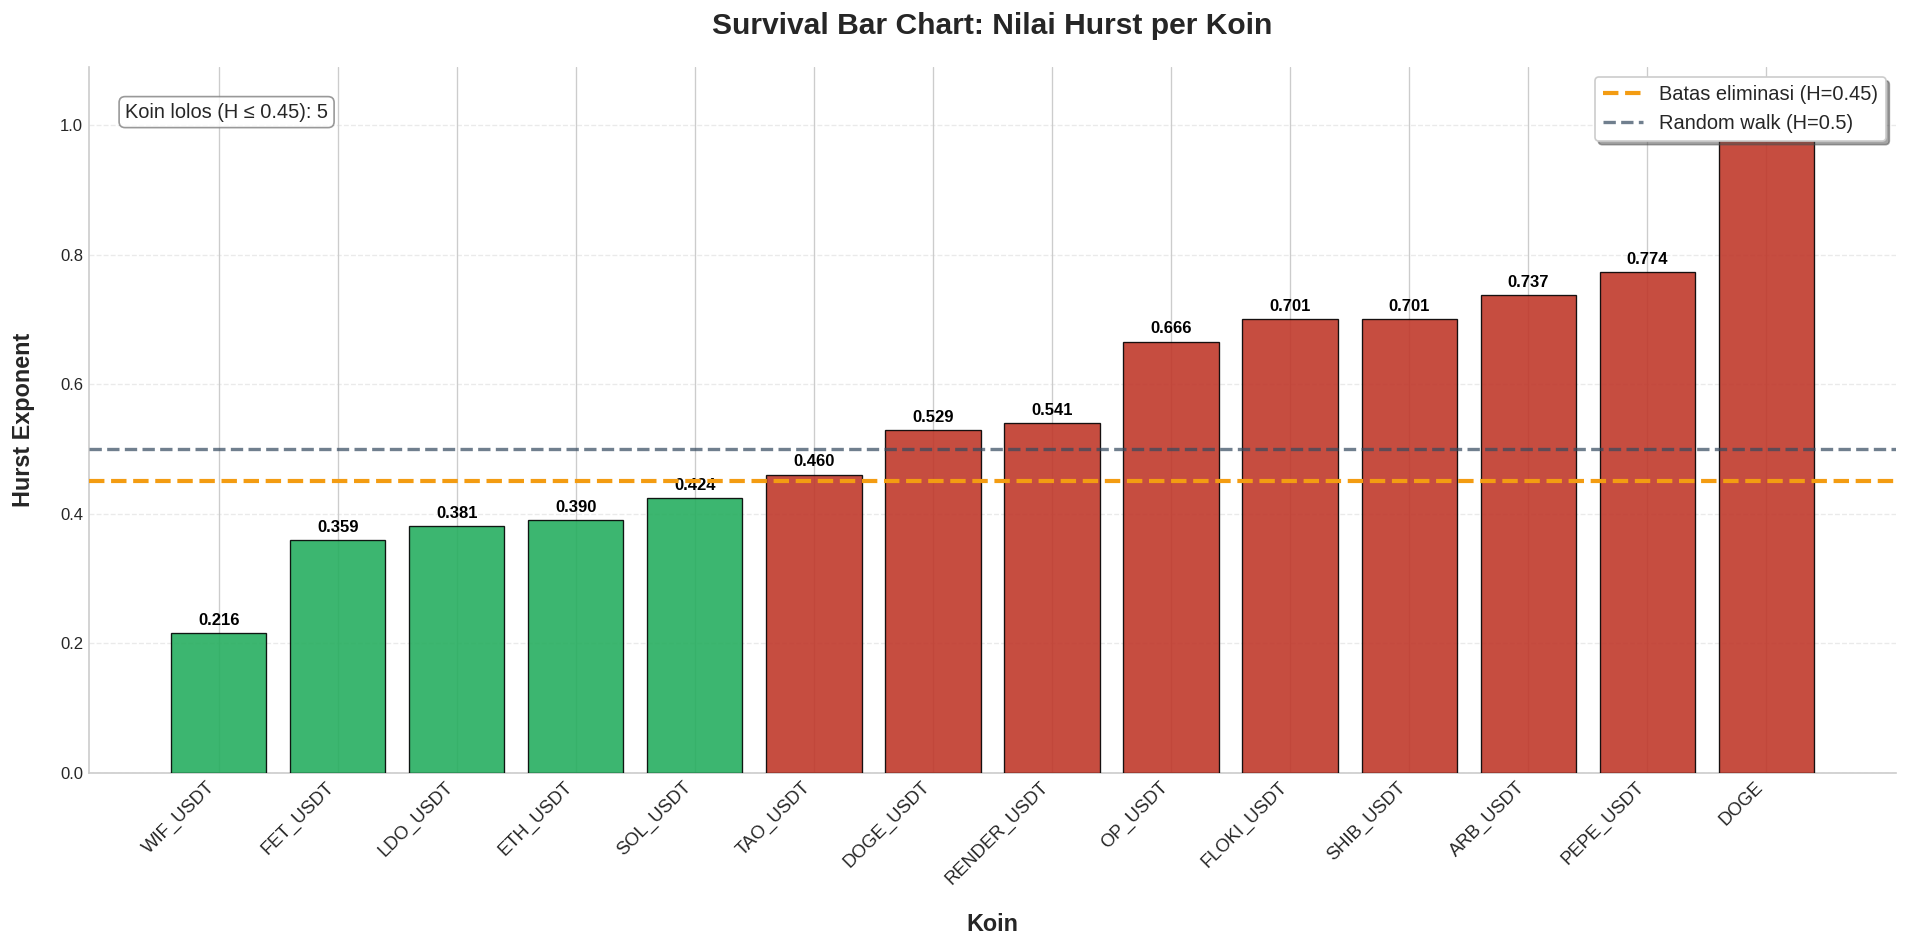

📁 Survival bar chart disimpan ke /home/bumip/orca/research/notebook/plots/survival_barchart.png


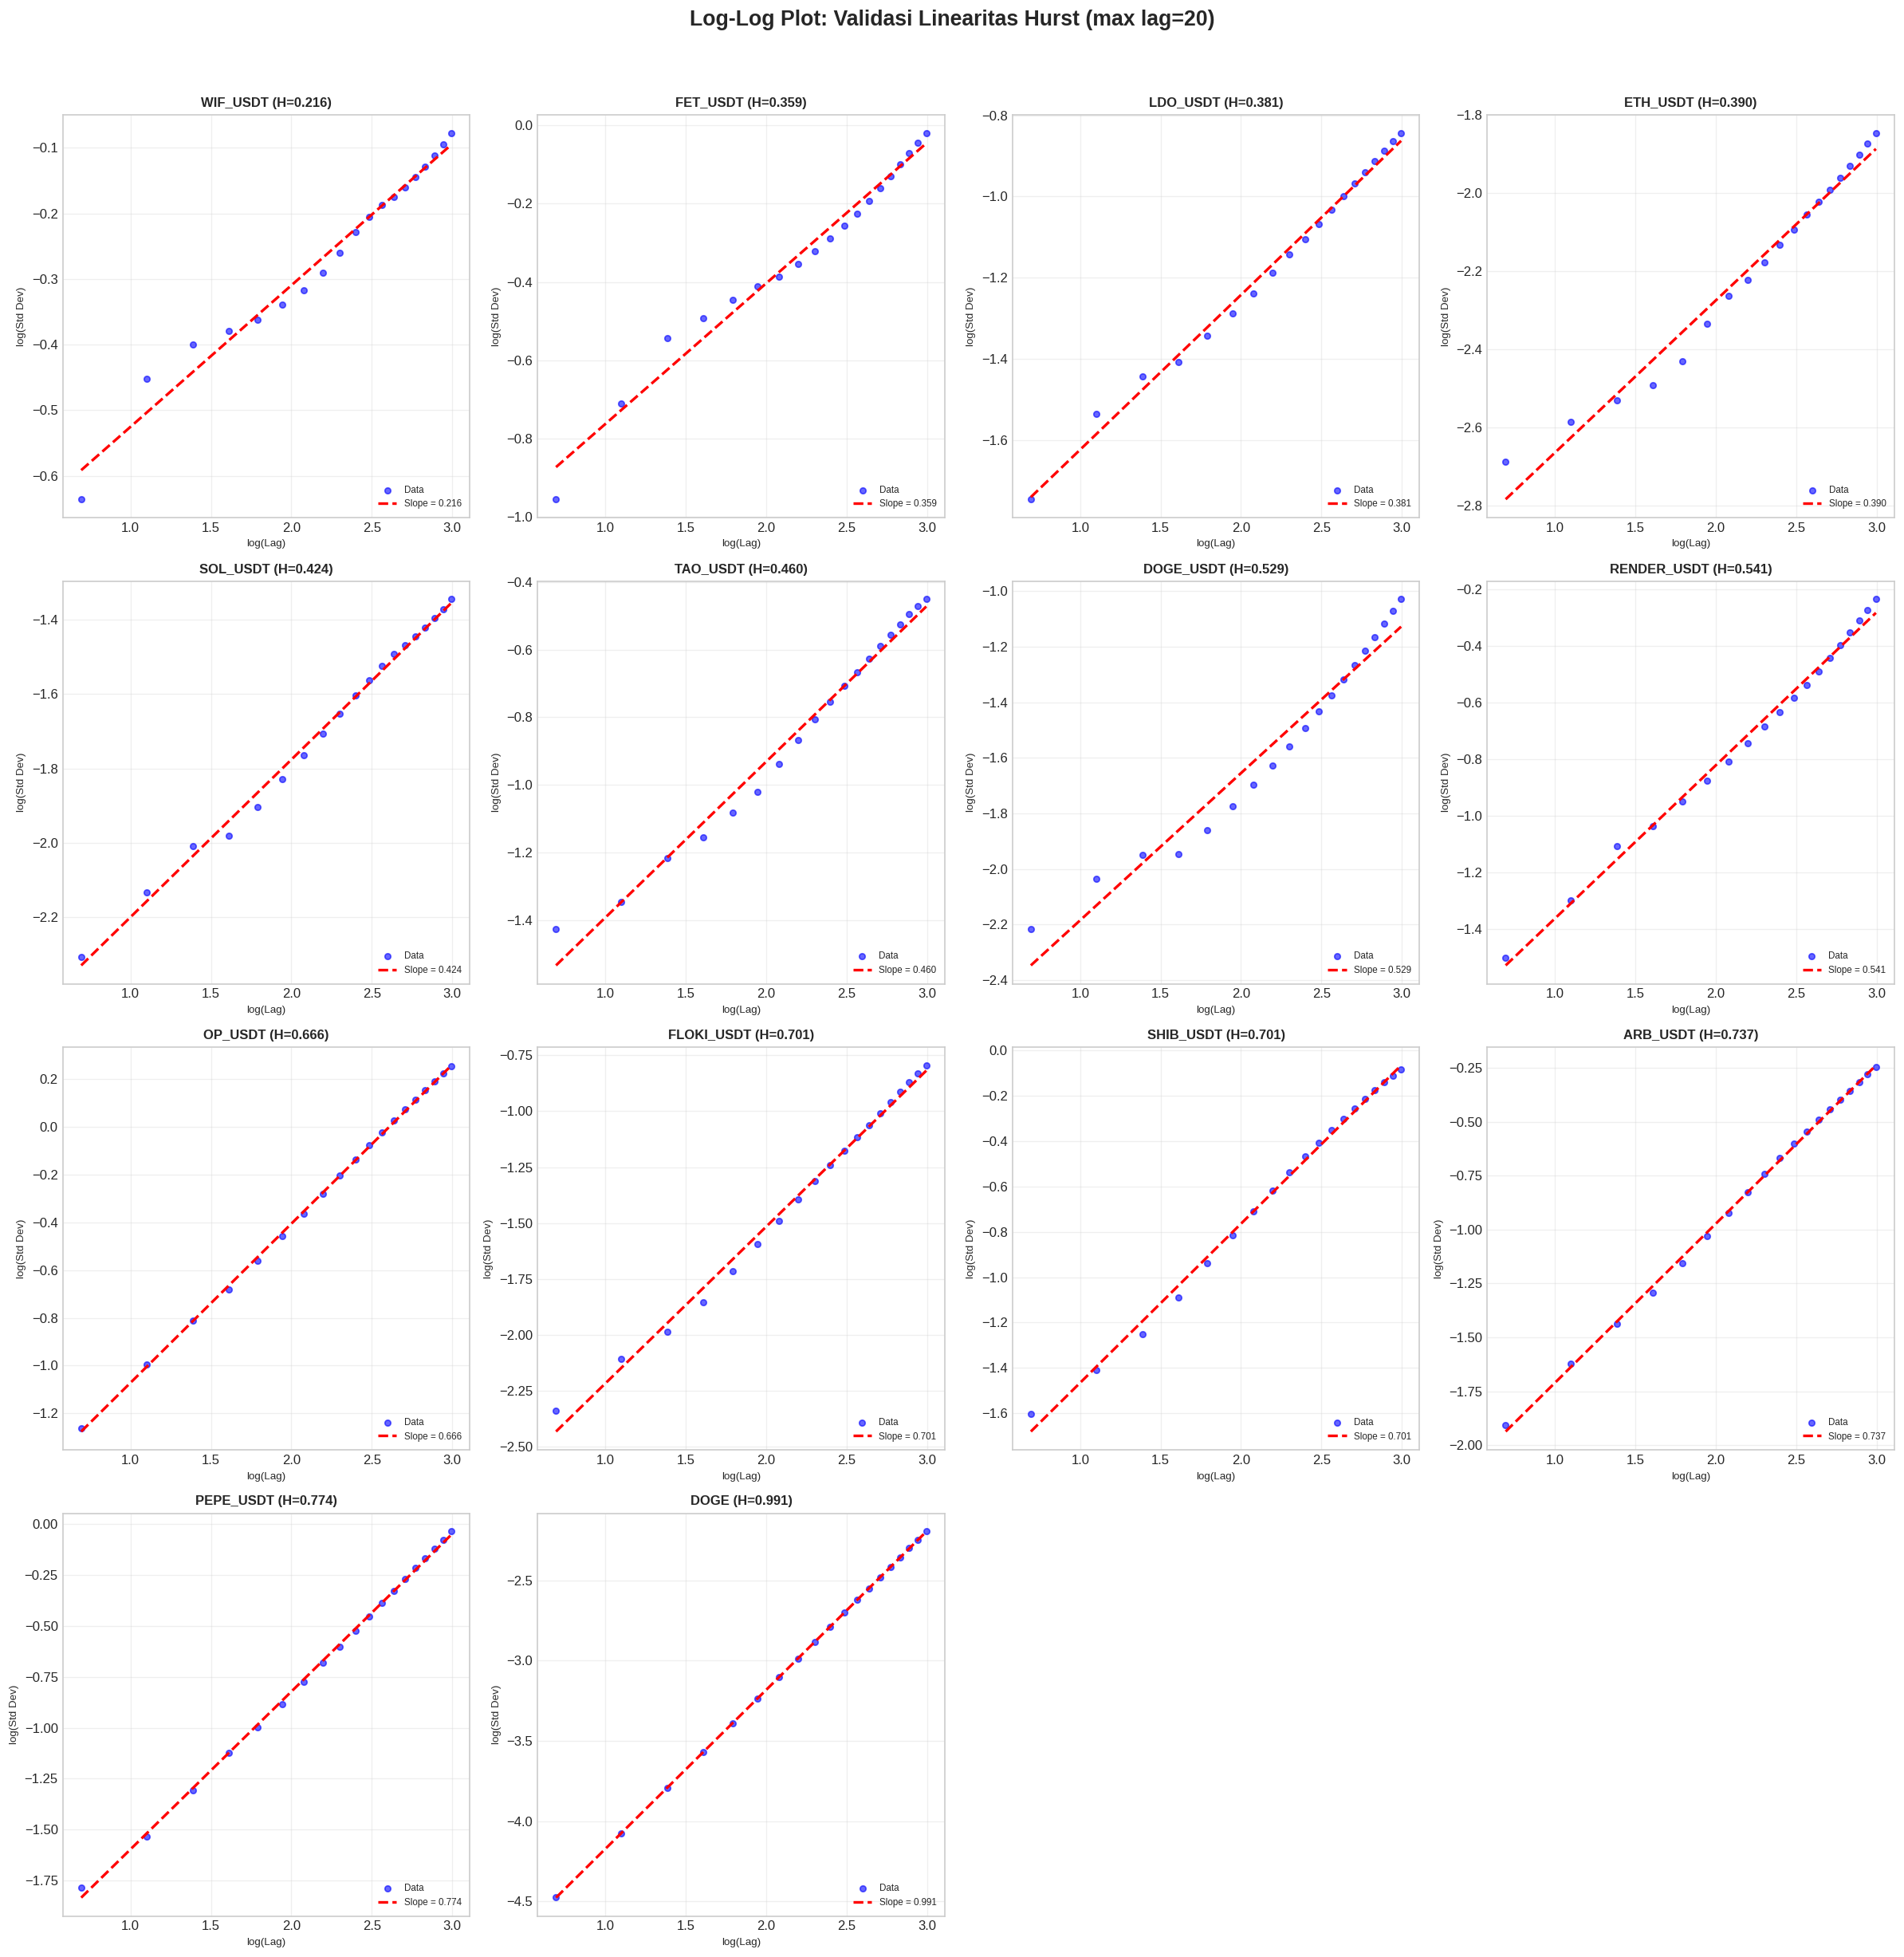

📁 Log-log plots disimpan ke /home/bumip/orca/research/notebook/plots/loglog_plots.png

========== DETAIL REGRESI LOG-LOG ==========
       Coin    Hurst    Slope  Intercept  R_squared  Std_err
   WIF_USDT 0.215521 0.215521  -0.740675   0.976137 0.008173
   FET_USDT 0.358926 0.358926  -1.121361   0.977948 0.013072
   LDO_USDT 0.380996 0.380996  -2.004244   0.993122 0.007690
   ETH_USDT 0.389866 0.389866  -3.054782   0.977216 0.014438
   SOL_USDT 0.423713 0.423713  -2.623823   0.994808 0.007424
   TAO_USDT 0.460466 0.460466  -1.852149   0.984525 0.014001
  DOGE_USDT 0.529397 0.529397  -2.713453   0.957388 0.027088
RENDER_USDT 0.540749 0.540749  -1.901840   0.994221 0.009999
    OP_USDT 0.666086 0.666086  -1.737643   0.999577 0.003322
 FLOKI_USDT 0.700503 0.700503  -2.917137   0.993744 0.013480
  SHIB_USDT 0.701227 0.701227  -2.166506   0.996133 0.010597
   ARB_USDT 0.737279 0.737279  -2.447582   0.998937 0.005833
  PEPE_USDT 0.773978 0.773978  -2.370319   0.999026 0.005861
       DOGE 0.

In [103]:
# %% [markdown]
# # Visualisasi Mikro dan Makro untuk Analisis Hurst
#
# **Mikro-Viz (Log-Log Plot)**: Untuk setiap koin, plot log(lag) vs log(standard deviation) beserta garis regresi. Ini memvalidasi linearitas hubungan yang mendasari perhitungan Hurst.
#
# **Makro-Viz (Survival Bar Chart)**: Bar chart terurut dari nilai Hurst dengan garis batas eliminasi (H=0.45) dan batas random walk (H=0.50). Koin dengan H≤0.45 berwarna hijau, sisanya merah.
#
# Semua visualisasi menggunakan gaya industrial grade dan bebas error font.

# %% [markdown]
# ## 0. Parameter Global
# Parameter yang digunakan konsisten dengan proses sebelumnya.

# %%
# Pastikan parameter global sudah didefinisikan, jika tidak beri nilai default
try:
    THRESHOLD
except NameError:
    THRESHOLD = 0.45
    print("⚠️ THRESHOLD tidak ditemukan, menggunakan default 0.45")

try:
    RANDOM_WALK_THRESHOLD
except NameError:
    RANDOM_WALK_THRESHOLD = 0.50
    print("⚠️ RANDOM_WALK_THRESHOLD tidak ditemukan, menggunakan default 0.50")

try:
    MAX_LAG
except NameError:
    MAX_LAG = 50
    print("⚠️ MAX_LAG tidak ditemukan, menggunakan default 50")

try:
    MAX_ROWS
except NameError:
    MAX_ROWS = 100000
    print("⚠️ MAX_ROWS tidak ditemukan, menggunakan default 100000")

# %% [markdown]
# ## 1. Import Pustaka dan Persiapan

from pathlib import Path

# %%
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Atur style
plt.style.use("seaborn-v0_8-whitegrid")

# Pastikan matplotlib dapat menampilkan di notebook
%matplotlib inline


# Fungsi untuk mendapatkan data log-log dari spread series
def get_loglog_data(spread_series, max_lag=MAX_LAG):
    """
    Menghitung standar deviasi untuk setiap lag (2..max_lag) dan mengembalikan log(lag) dan log(std).
    """
    spread_clean = spread_series.dropna().values
    if len(spread_clean) < max_lag + 10:
        return None, None
    lags = np.arange(2, max_lag + 1)
    std_values = []
    for lag in lags:
        diff = spread_clean[lag:] - spread_clean[:-lag]
        std_val = np.std(diff, ddof=1)
        if std_val > 0:
            std_values.append(std_val)
        else:
            std_values.append(np.nan)
    valid = ~np.isnan(std_values)
    if valid.sum() < 2:
        return None, None
    log_lags = np.log(lags[valid])
    log_std = np.log(np.array(std_values)[valid])
    return log_lags, log_std


# %% [markdown]
# ## 2. Makro-Viz: Survival Bar Chart

# %%
# Gunakan df_leader yang sudah ada
if "df_leader" not in locals():
    # Coba muat dari file CSV
    csv_path = Path.cwd() / "hurst_leaderboard.csv"
    if csv_path.exists():
        df_leader = pd.read_csv(csv_path)
        print("✅ Data dimuat dari hurst_leaderboard.csv")
    else:
        raise NameError(
            "df_leader tidak ditemukan. Jalankan sel leaderboard terlebih dahulu."
        )

# Urutkan berdasarkan Hurst
df_plot = (
    df_leader[["Coin", "Hurst"]]
    .sort_values("Hurst", ascending=True)
    .reset_index(drop=True)
)

# Setup figure
fig, ax = plt.subplots(figsize=(16, 8), dpi=120)

# Warna: hijau jika H ≤ THRESHOLD, merah jika lebih
colors = ["#27ae60" if h <= THRESHOLD else "#c0392b" for h in df_plot["Hurst"]]
bars = ax.bar(
    df_plot["Coin"],
    df_plot["Hurst"],
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)

# Garis batas
ax.axhline(
    y=THRESHOLD,
    color="#f39c12",
    linestyle="--",
    linewidth=2.5,
    label=f"Batas eliminasi (H={THRESHOLD})",
    zorder=5,
)
ax.axhline(
    y=RANDOM_WALK_THRESHOLD,
    color="#34495e",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label=f"Random walk (H={RANDOM_WALK_THRESHOLD})",
    zorder=5,
)

# Label dan judul
ax.set_xlabel("Koin", fontsize=14, fontweight="bold", labelpad=15)
ax.set_ylabel("Hurst Exponent", fontsize=14, fontweight="bold", labelpad=15)
ax.set_title(
    "Survival Bar Chart: Nilai Hurst per Koin", fontsize=18, fontweight="bold", pad=20
)

# Atur ticks sumbu x
ax.set_xticks(range(len(df_plot["Coin"])))
ax.set_xticklabels(df_plot["Coin"], rotation=45, ha="right", fontsize=11)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

# Anotasi nilai di atas bar
for bar, h in zip(bars, df_plot["Hurst"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + 0.008,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        fontweight="bold",
    )

# Legenda
ax.legend(loc="upper right", frameon=True, fancybox=True, shadow=True, fontsize=12)

# Hilangkan spines atas dan kanan
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Batas y
ax.set_ylim(0, max(df_plot["Hurst"]) * 1.1)

# Anotasi jumlah koin lolos (tanpa emoji untuk menghindari font issue)
lolos = sum(df_plot["Hurst"] <= THRESHOLD)
ax.text(
    0.02,
    0.95,
    f"Koin lolos (H ≤ {THRESHOLD}): {lolos}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"),
)

plt.tight_layout()
plt.show()

# Simpan
output_dir = Path.cwd() / "plots"
output_dir.mkdir(exist_ok=True)
fig.savefig(
    output_dir / "survival_barchart.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
print(f"📁 Survival bar chart disimpan ke {output_dir}/survival_barchart.png")

# %% [markdown]
# ## 3. Mikro-Viz: Log-Log Plot untuk Setiap Koin
#
# Untuk setiap koin, kita plot log(lag) vs log(standard deviation) beserta garis regresi linier.
# Ini memverifikasi bahwa hubungan log-log bersifat linear, yang merupakan asumsi dasar metode Hurst.


# %%
# Fungsi untuk memuat data spread (sama seperti sebelumnya)
def load_spread_for_viz(symbol, data_path, max_rows=MAX_ROWS):
    spread_col = f"spread_{symbol}"
    columns = ["timestamp", spread_col]
    files = sorted(data_path.glob("**/*.parquet"))
    if not files:
        return None
    data_frames = []
    for file in files:
        try:
            df_part = pd.read_parquet(file, columns=columns)
        except:
            continue
        if not df_part.empty:
            data_frames.append(df_part)
    if not data_frames:
        return None
    df = pd.concat(data_frames, ignore_index=True)
    df = df.sort_values("timestamp").reset_index(drop=True)
    if len(df) > max_rows:
        df = df.iloc[-max_rows:].reset_index(drop=True)
    return df[spread_col]


# Tentukan path data
if "SILVER_LAKE_PATH" not in locals():
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent.parent
    SILVER_LAKE_PATH = project_root / "data" / "silver"

# Ambil daftar koin dari df_plot
coins = df_plot["Coin"].tolist()
n_coins = len(coins)
n_cols = 4
n_rows = (n_coins + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), dpi=120)
axes = axes.flatten()

for i, coin in enumerate(coins):
    ax = axes[i]
    spread = load_spread_for_viz(coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS)
    if spread is None or spread.empty:
        ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center", fontsize=12)
        ax.set_title(f"{coin}", fontsize=10)
        continue

    log_lags, log_std = get_loglog_data(spread, max_lag=MAX_LAG)
    if log_lags is None:
        ax.text(0.5, 0.5, "Data tidak cukup", ha="center", va="center", fontsize=12)
        ax.set_title(f"{coin}", fontsize=10)
        continue

    # Scatter plot
    ax.scatter(log_lags, log_std, s=20, color="blue", alpha=0.6, label="Data")

    # Regresi linier
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_lags, log_std)
    x_fit = np.linspace(log_lags.min(), log_lags.max(), 100)
    y_fit = intercept + slope * x_fit
    ax.plot(x_fit, y_fit, "r--", linewidth=2, label=f"Slope = {slope:.3f}")

    ax.set_xlabel("log(Lag)", fontsize=8)
    ax.set_ylabel("log(Std Dev)", fontsize=8)
    ax.set_title(f"{coin} (H={slope:.3f})", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(True, alpha=0.3)

# Sembunyikan subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Log-Log Plot: Validasi Linearitas Hurst (max lag={MAX_LAG})",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

# Simpan
fig.savefig(
    output_dir / "loglog_plots.png", dpi=300, bbox_inches="tight", facecolor="white"
)
print(f"📁 Log-log plots disimpan ke {output_dir}/loglog_plots.png")

# %% [markdown]
# ## 4. Detail Statistik per Koin (Opsional)
#
# Tabel berikut menampilkan nilai Hurst, slope, intercept, dan R² dari regresi log-log.

# %%
# Kumpulkan data regresi untuk setiap koin
reg_results = []
for coin in coins:
    spread = load_spread_for_viz(coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS)
    if spread is None:
        continue
    log_lags, log_std = get_loglog_data(spread, max_lag=MAX_LAG)
    if log_lags is None:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_lags, log_std)
    reg_results.append(
        {
            "Coin": coin,
            "Hurst": df_plot[df_plot["Coin"] == coin]["Hurst"].values[0],
            "Slope": slope,
            "Intercept": intercept,
            "R_squared": r_value**2,
            "Std_err": std_err,
        }
    )

df_reg = pd.DataFrame(reg_results)
df_reg = df_reg.sort_values("Hurst", ascending=True).reset_index(drop=True)

print("\n========== DETAIL REGRESI LOG-LOG ==========")
print(df_reg.to_string(index=False))

# Simpan ke CSV
df_reg.to_csv(output_dir / "hurst_regression_details.csv", index=False)
print(f"\n📁 Detail regresi disimpan ke {output_dir}/hurst_regression_details.csv")

In [104]:
if "hurst_results" not in locals():
    raise NameError(
        "hurst_results tidak ditemukan. Jalankan screening Hurst terlebih dahulu."
    )

# Ambil koin dengan Hurst ≤ 0.45
koin_lolos_hurst = [
    sym for sym, h in hurst_results.items() if h is not None and h <= 0.45
]
print(f"🔍 Koin dengan Hurst ≤ 0.45: {len(koin_lolos_hurst)}")
if not koin_lolos_hurst:
    print("Tidak ada koin yang lolos seleksi Hurst. Lewati uji ADF.")
else:
    print("Daftar koin:", koin_lolos_hurst)

# Pastikan SILVER_LAKE_PATH terdefinisi
if "SILVER_LAKE_PATH" not in locals():
    notebook_dir = Path.cwd()
    project_root = notebook_dir.parent.parent
    SILVER_LAKE_PATH = project_root / "data" / "silver"
    print(f"📁 Silver Lake path: {SILVER_LAKE_PATH}")

🔍 Koin dengan Hurst ≤ 0.45: 5
Daftar koin: ['FET_USDT', 'ETH_USDT', 'LDO_USDT', 'SOL_USDT', 'WIF_USDT']


In [105]:
# %% [markdown]
# ## Cell 2: Eksekusi Uji ADF untuk Koin Lolos Hurst
#
# Menggunakan data yang sama seperti pada perhitungan Hurst (max `MAX_ROWS` baris terbaru).
# Proses dilakukan secara sekuensial karena jumlah koin lolos biasanya sedikit.

# %%
# Jika tidak ada koin lolos, hentikan
if not koin_lolos_hurst:
    print("Tidak ada koin untuk diuji ADF.")
else:
    # Definisikan fungsi adf_test_spread jika belum ada
    def adf_test_spread(
        symbol: str, spread_series: pd.Series, alpha: float = 0.05
    ) -> Dict[str, object]:
        """
        Jalankan uji ADF pada spread series dan kembalikan hasil lengkap.
        """
        if spread_series.empty:
            return {
                "symbol": symbol,
                "adf_statistic": np.nan,
                "p_value": np.nan,
                "critical_values": {},
                "used_lag": np.nan,
                "is_stationary": False,
                "warning": "Data kosong",
            }
        clean = spread_series.dropna()
        if len(clean) < 10:
            return {
                "symbol": symbol,
                "adf_statistic": np.nan,
                "p_value": np.nan,
                "critical_values": {},
                "used_lag": np.nan,
                "is_stationary": False,
                "warning": "Data terlalu pendek setelah drop NaN",
            }
        result = adfuller(clean, autolag="AIC")
        adf_stat, p_value, used_lag, nobs, crit_vals, _ = result
        is_stationary = p_value < alpha
        warning = ""
        if p_value < 0.05 and p_value > 0.045:
            warning = "⚠️ Borderline: p-value antara 0.045 dan 0.05"
        elif p_value >= 0.05:
            warning = "❌ Tidak stasioner"
        return {
            "symbol": symbol,
            "adf_statistic": adf_stat,
            "p_value": p_value,
            "critical_values": crit_vals,
            "used_lag": used_lag,
            "is_stationary": is_stationary,
            "warning": warning,
        }

    adf_results = {}
    print("🔬 Memulai uji ADF...\n")
    for coin in koin_lolos_hurst:
        # Muat data spread dengan max_rows = MAX_ROWS (sama seperti Hurst)
        spread = load_full_spread_for_symbol(coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS)
        if spread is None:
            print(f"{coin:15} : GAGAL (data tidak tersedia)")
            continue
        hasil = adf_test_spread(coin, spread, alpha=0.05)
        adf_results[coin] = hasil

        if np.isnan(hasil["p_value"]):
            print(f"{coin:15} : GAGAL (data tidak cukup)")
        else:
            stat = hasil["adf_statistic"]
            p = hasil["p_value"]
            stat_str = f"{stat:.4f}" if not np.isnan(stat) else "NaN"
            p_str = f"{p:.6f}" if not np.isnan(p) else "NaN"
            status = "STASIONER ✅" if hasil["is_stationary"] else "TIDAK STASIONER ❌"
            warn = f" ({hasil['warning']})" if hasil["warning"] else ""
            print(
                f"{coin:15} : ADF stat = {stat_str:>8}, p-value = {p_str:>10} → {status}{warn}"
            )

    # Simpan hasil ke variabel global untuk cell berikutnya
    ADF_RESULTS = adf_results
    print("\n✅ Uji ADF selesai. Hasil tersimpan dalam variabel `ADF_RESULTS`.")

🔬 Memulai uji ADF...

FET_USDT        : ADF stat =  -1.7490, p-value =   0.406045 → TIDAK STASIONER ❌ (❌ Tidak stasioner)
ETH_USDT        : ADF stat =  -1.1665, p-value =   0.687858 → TIDAK STASIONER ❌ (❌ Tidak stasioner)
LDO_USDT        : ADF stat =  -4.2225, p-value =   0.000603 → STASIONER ✅
SOL_USDT        : ADF stat =  -2.3957, p-value =   0.142962 → TIDAK STASIONER ❌ (❌ Tidak stasioner)
WIF_USDT        : ADF stat =  -2.3731, p-value =   0.149484 → TIDAK STASIONER ❌ (❌ Tidak stasioner)

✅ Uji ADF selesai. Hasil tersimpan dalam variabel `ADF_RESULTS`.


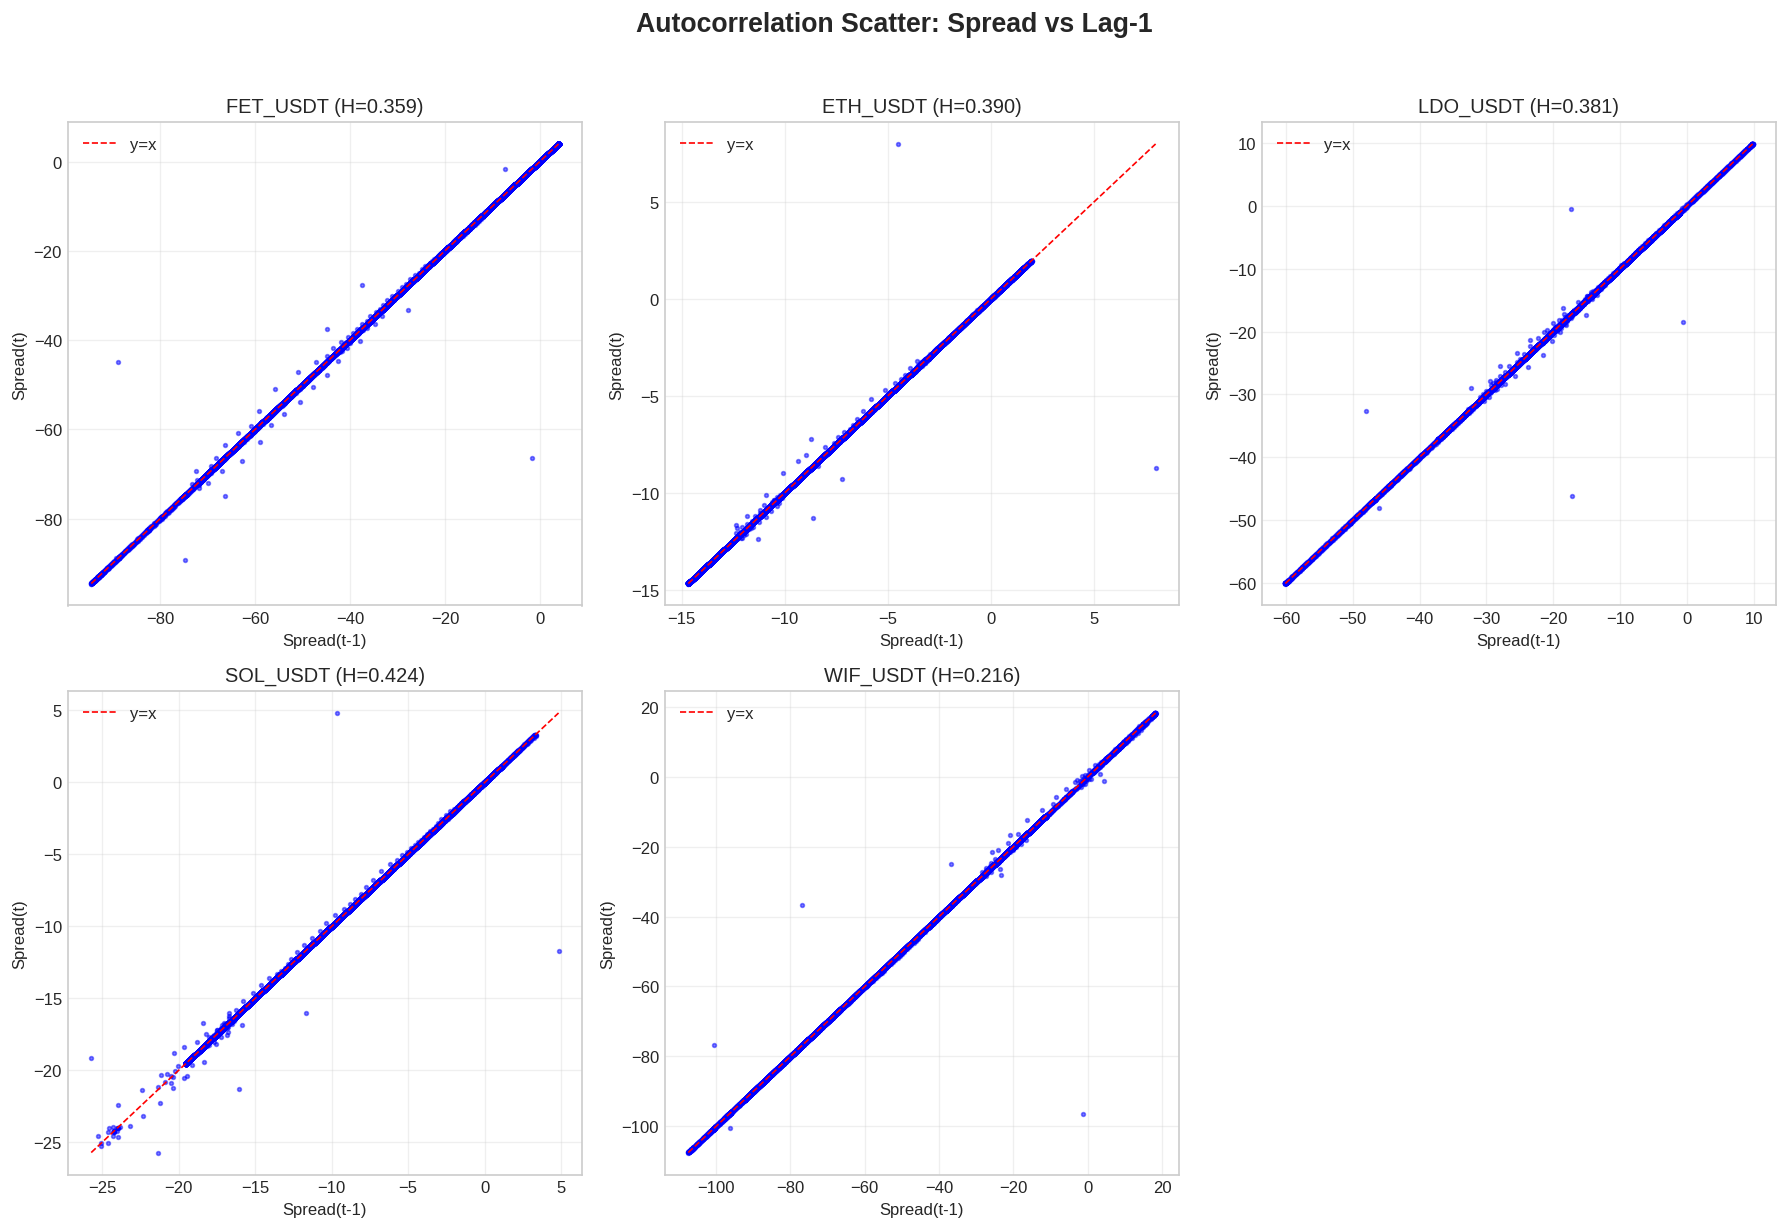

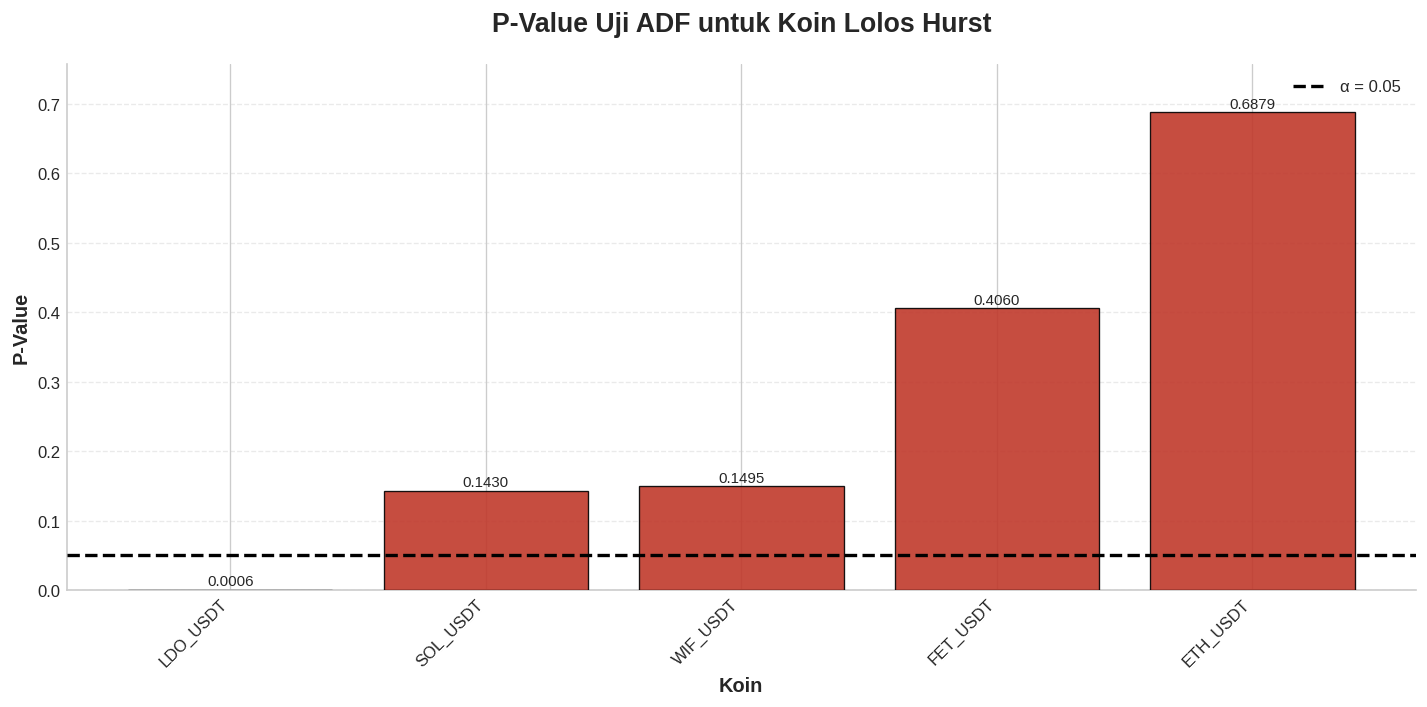

📁 P-value bar chart disimpan ke /home/bumip/orca/research/notebook/plots/adf_pvalue_barchart.png


In [106]:
# %% [markdown]
# ## Cell 3: Visualisasi Lanjutan untuk Koin Lolos Hurst
#
# **Micro-Viz (Autocorrelation Scatter)**: Scatter plot antara spread saat ini (lag 0) dan spread dengan lag 1. Ini memberikan gambaran visual tentang korelasi serial dan mean-reversion.
#
# **Macro-Viz (P-Value Bar Chart)**: Bar chart p-value dari uji ADF untuk koin yang telah diuji. Garis batas di y=0.05.

# %% [markdown]
# ### 3.1 Autocorrelation Scatter untuk Setiap Koin Lolos Hurst

# %%
# Pastikan koin_lolos_hurst terdefinisi (dari cell 1)
if "koin_lolos_hurst" not in locals() or not koin_lolos_hurst:
    print("Tidak ada koin lolos Hurst untuk visualisasi autocorrelation.")
else:
    # Tentukan layout grid
    n_plots = len(koin_lolos_hurst)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), dpi=120)
    axes = axes.flatten() if n_plots > 1 else [axes]

    for idx, coin in enumerate(koin_lolos_hurst):
        ax = axes[idx]
        # Muat data spread
        spread = load_full_spread_for_symbol(coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS)
        if spread is None or spread.empty:
            ax.text(0.5, 0.5, "Data tidak tersedia", ha="center", va="center")
            ax.set_title(f"{coin}")
            continue

        # Buat lag 1
        spread_lag1 = spread.shift(1)
        # Gabungkan dan hilangkan NaN
        df_scatter = pd.DataFrame({"spread": spread, "lag1": spread_lag1}).dropna()
        if len(df_scatter) < 10:
            ax.text(0.5, 0.5, "Data terlalu sedikit", ha="center", va="center")
            ax.set_title(f"{coin}")
            continue

        # Scatter plot
        ax.scatter(
            df_scatter["lag1"], df_scatter["spread"], s=5, alpha=0.5, color="blue"
        )
        # Garis y=x untuk referensi
        min_val = min(df_scatter.min())
        max_val = max(df_scatter.max())
        ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1, label="y=x")
        ax.set_xlabel("Spread(t-1)")
        ax.set_ylabel("Spread(t)")
        ax.set_title(f"{coin} (H={hurst_results[coin]:.3f})")
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Sembunyikan subplot yang tidak terpakai
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Autocorrelation Scatter: Spread vs Lag-1",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ### 3.2 P-Value Bar Chart untuk Hasil ADF

# %%
# Pastikan ADF_RESULTS tersedia dari cell 2
if "ADF_RESULTS" not in locals() or not ADF_RESULTS:
    print("Tidak ada hasil ADF untuk divisualisasikan.")
else:
    # Buat DataFrame dari hasil ADF
    df_adf_viz = (
        pd.DataFrame(
            [
                {"Coin": k, "p_value": v["p_value"], "stationary": v["is_stationary"]}
                for k, v in ADF_RESULTS.items()
                if not np.isnan(v["p_value"])
            ]
        )
        .sort_values("p_value", ascending=True)
        .reset_index(drop=True)
    )

    if df_adf_viz.empty:
        print("Tidak ada data p-value valid.")
    else:
        fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

        # Warna: hijau jika p ≤ 0.05, merah jika lebih
        colors = ["#27ae60" if p <= 0.05 else "#c0392b" for p in df_adf_viz["p_value"]]
        bars = ax.bar(
            df_adf_viz["Coin"],
            df_adf_viz["p_value"],
            color=colors,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
            zorder=3,
        )

        # Garis batas
        ax.axhline(
            y=0.05,
            color="black",
            linestyle="--",
            linewidth=2,
            label="α = 0.05",
            zorder=5,
        )

        # Label dan judul
        ax.set_xlabel("Koin", fontsize=12, fontweight="bold")
        ax.set_ylabel("P-Value", fontsize=12, fontweight="bold")
        ax.set_title(
            "P-Value Uji ADF untuk Koin Lolos Hurst",
            fontsize=16,
            fontweight="bold",
            pad=20,
        )

        # Rotasi label x
        ax.set_xticks(range(len(df_adf_viz["Coin"])))
        ax.set_xticklabels(df_adf_viz["Coin"], rotation=45, ha="right", fontsize=10)

        # Grid
        ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

        # Anotasi nilai di atas bar
        for bar, p in zip(bars, df_adf_viz["p_value"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f"{p:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        ax.legend()
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_ylim(0, max(df_adf_viz["p_value"]) * 1.1)

        plt.tight_layout()
        plt.show()

        # Simpan
        fig.savefig(
            output_dir / "adf_pvalue_barchart.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"📁 P-value bar chart disimpan ke {output_dir}/adf_pvalue_barchart.png")

In [120]:
HALF_LIFE_LIMIT = 1440
try:
    MAX_ROWS
except NameError:
    MAX_ROWS = 100000
    print("⚠️ MAX_ROWS tidak ditemukan, menggunakan default 100000")

try:
    HALF_LIFE_LIMIT
except NameError:
    HALF_LIFE_LIMIT = 1440  # 24 jam dalam menit
    print("⚠️ HALF_LIFE_LIMIT tidak ditemukan, menggunakan default 1440 menit")


# Fungsi untuk menghitung half-life
def compute_half_life_ou(
    spread: pd.Series,
) -> Tuple[Optional[float], Optional[float], str]:
    """
    Hitung half‑life mean reversion menggunakan regresi OLS pada persamaan diferensial Ornstein‑Uhlenbeck.

    Parameters
    ----------
    spread : pd.Series
        Series spread (boleh mengandung NaN, akan di-drop).

    Returns
    -------
    Tuple[Optional[float], Optional[float], str]
        (lambda, half_life, message)
        lambda: koefisien regresi (negatif jika mean‑reverting)
        half_life: dalam satuan periode (menit) atau np.inf jika lambda >= 0
        message: status atau peringatan
    """
    if spread.empty:
        return None, None, "Data kosong"

    clean = spread.dropna()
    if len(clean) < 10:
        return None, None, "Data terlalu pendek setelah drop NaN"

    spread_lag = clean.shift(1)
    spread_diff = clean.diff()

    X = spread_lag.iloc[1:]
    Y = spread_diff.iloc[1:]

    if len(X) < 5:
        return None, None, "Observasi terlalu sedikit setelah lag"

    X_with_const = sm.add_constant(X)

    try:
        model = sm.OLS(Y, X_with_const).fit()
    except Exception as e:
        return None, None, f"Regresi gagal: {e}"

    lam = model.params.iloc[1]

    if lam >= 0:
        return lam, np.inf, "Lambda >= 0, tidak mean‑reverting"

    half_life = -np.log(2) / lam
    return lam, half_life, "Sukses"


# %% [markdown]
# ### Tentukan Koin yang Akan Dianalisis
# Kita hanya akan memproses koin yang:
# 1. Lolos Hurst (H ≤ THRESHOLD)
# 2. Stasioner menurut ADF (p ≤ 0.05)

# %%
# Pastikan hasil Hurst dan ADF tersedia
if "hurst_results" not in locals():
    raise NameError(
        "hurst_results tidak ditemukan. Jalankan screening Hurst terlebih dahulu."
    )

if "ADF_RESULTS" not in locals():
    raise NameError("ADF_RESULTS tidak ditemukan. Jalankan uji ADF terlebih dahulu.")

# Filter koin yang lolos kedua tes
koin_lolos_ou = []
for coin in hurst_results:
    if coin not in ADF_RESULTS:
        continue
    h = hurst_results[coin]
    adf = ADF_RESULTS[coin]
    if h is not None and h <= THRESHOLD and adf.get("is_stationary", False):
        koin_lolos_ou.append(coin)

print(f"🔍 Koin yang lolos Hurst dan ADF: {len(koin_lolos_ou)}")
if not koin_lolos_ou:
    print("Tidak ada koin yang memenuhi kedua kriteria. Proses OU dihentikan.")
else:
    print("Daftar koin:", koin_lolos_ou)

# %% [markdown]
# ### Hitung Parameter OU untuk Setiap Koin Lolos

# %%
if koin_lolos_ou:
    ou_results = {}
    print("🚀 Memulai perhitungan parameter OU...\n")
    for coin in koin_lolos_ou:
        # Muat data spread dengan MAX_ROWS
        spread = load_full_spread_for_symbol(coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS)
        if spread is None:
            print(f"{coin:15} : GAGAL (data tidak tersedia)")
            continue
        lam, half_life, message = compute_half_life_ou(spread)
        ou_results[coin] = {"lambda": lam, "half_life": half_life, "message": message}
        if lam is not None:
            print(
                f"{coin:15} : λ = {lam:.6f}, half-life = {half_life:.2f} menit, status: {message}"
            )
        else:
            print(f"{coin:15} : GAGAL ({message})")

    print("\n✅ Perhitungan OU selesai. Hasil tersimpan dalam variabel `OU_RESULTS`.")
    OU_RESULTS = ou_results
else:
    print("Tidak ada koin untuk diproses.")

🔍 Koin yang lolos Hurst dan ADF: 1
Daftar koin: ['LDO_USDT']
🚀 Memulai perhitungan parameter OU...

LDO_USDT        : λ = -0.000197, half-life = 3525.45 menit, status: Sukses

✅ Perhitungan OU selesai. Hasil tersimpan dalam variabel `OU_RESULTS`.


In [123]:
# %% [markdown]
# ## Visualisasi Ornstein-Uhlenbeck (U-O)

# %% [markdown]
# ### 1. Gravity Scatter Plot (Micro-Viz)
# Menampilkan hubungan antara spread lag (S_{t-1}) dan perubahan spread (ΔS_t) beserta garis regresi OLS. Slope negatif (λ) mengindikasikan mean-reversion.

from pathlib import Path

# %%
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pastikan hasil OU tersedia
if "OU_RESULTS" not in locals() or not OU_RESULTS:
    print("Tidak ada hasil OU untuk divisualisasikan.")
else:
    n_plots = len(koin_lolos_ou)
    if n_plots == 0:
        print("Tidak ada koin untuk diplot.")
    else:
        n_cols = 3
        n_rows = (n_plots + n_cols - 1) // n_cols
        # Gunakan squeeze=False agar axes selalu berbentuk array 2D
        fig, axes = plt.subplots(
            n_rows, n_cols, figsize=(15, 5 * n_rows), dpi=120, squeeze=False
        )
        axes_flat = axes.flatten()

        for idx, coin in enumerate(koin_lolos_ou):
            ax = axes_flat[idx]
            spread = load_full_spread_for_symbol(
                coin, SILVER_LAKE_PATH, max_rows=MAX_ROWS
            )
            if spread is None or spread.empty:
                ax.text(
                    0.5,
                    0.5,
                    "Data tidak tersedia",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{coin}")
                continue

            clean = spread.dropna()
            if len(clean) < 10:
                ax.text(
                    0.5,
                    0.5,
                    "Data terlalu sedikit",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{coin}")
                continue

            spread_lag = clean.shift(1)
            spread_diff = clean.diff()
            df_scatter = pd.DataFrame({"lag": spread_lag, "diff": spread_diff}).dropna()
            if len(df_scatter) < 10:
                ax.text(
                    0.5,
                    0.5,
                    "Data tidak cukup",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
                ax.set_title(f"{coin}")
                continue

            ax.scatter(
                df_scatter["lag"], df_scatter["diff"], s=5, alpha=0.5, color="blue"
            )
            X = df_scatter["lag"].values
            Y = df_scatter["diff"].values
            coeffs = np.polyfit(X, Y, 1)
            slope = coeffs[0]
            intercept = coeffs[1]
            x_fit = np.linspace(X.min(), X.max(), 100)
            y_fit = intercept + slope * x_fit
            ax.plot(x_fit, y_fit, "r-", linewidth=2, label=f"λ = {slope:.4f}")
            ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
            ax.set_xlabel("Spread(t-1)")
            ax.set_ylabel("ΔSpread(t)")
            ax.set_title(
                f"{coin} (half-life: {OU_RESULTS[coin]['half_life']:.1f} menit)"
            )
            ax.legend()
            ax.grid(True, alpha=0.3)

        # Sembunyikan subplot yang tidak terpakai
        for j in range(n_plots, len(axes_flat)):
            axes_flat[j].axis("off")

        plt.suptitle(
            "Gravity Scatter: Perubahan Spread vs Spread Lag",
            fontsize=16,
            fontweight="bold",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()

        # Simpan plot
        output_dir = Path.cwd() / "plots"
        output_dir.mkdir(exist_ok=True)
        fig.savefig(
            output_dir / "gravity_scatter.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(f"📁 Gravity scatter plot disimpan ke {output_dir}/gravity_scatter.png")

# %% [markdown]
# ### 2. Hourglass Horizontal Bar (Macro-Viz)
# Menampilkan half-life dalam satuan jam untuk setiap koin. Garis batas 24 jam.

# %%
if "OU_RESULTS" not in locals() or not OU_RESULTS:
    print("Tidak ada hasil OU untuk divisualisasikan.")
else:
    # Buat DataFrame half-life dalam jam
    df_hl = (
        pd.DataFrame(
            [
                {
                    "Coin": coin,
                    "half_life_hours": (
                        data["half_life"] / 60
                        if data["half_life"] is not None and data["half_life"] != np.inf
                        else np.nan
                    ),
                }
                for coin, data in OU_RESULTS.items()
            ]
        )
        .dropna()
        .sort_values("half_life_hours", ascending=True)
        .reset_index(drop=True)
    )

    if df_hl.empty:
        print("Tidak ada data half-life valid.")
    else:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=120)
        colors = ["#27ae60" if h <= 24 else "#c0392b" for h in df_hl["half_life_hours"]]
        bars = ax.barh(
            df_hl["Coin"],
            df_hl["half_life_hours"],
            color=colors,
            alpha=0.8,
            edgecolor="black",
        )
        ax.axvline(x=24, color="red", linestyle="--", linewidth=2, label="Batas 24 jam")
        ax.set_xlabel("Half-Life (jam)", fontsize=12, fontweight="bold")
        ax.set_ylabel("Koin", fontsize=12, fontweight="bold")
        ax.set_title(
            "Half-Life Mean Reversion (dalam jam)",
            fontsize=16,
            fontweight="bold",
            pad=20,
        )

        # Tambahkan nilai di ujung bar
        for bar, h in zip(bars, df_hl["half_life_hours"]):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{h:.1f} jam",
                ha="left",
                va="center",
                fontsize=10,
            )

        ax.legend()
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

        # Simpan plot
        output_dir = Path.cwd() / "plots"
        output_dir.mkdir(exist_ok=True)
        fig.savefig(
            output_dir / "half_life_horizontal.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        print(
            f"📁 Half-life horizontal bar chart disimpan ke {output_dir}/half_life_horizontal.png"
        )

/tmp/ipykernel_45783/2267923885.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


📁 Gravity scatter plot disimpan ke /home/bumip/orca/research/notebook/plots/gravity_scatter.png


/tmp/ipykernel_45783/2267923885.py:116: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


📁 Half-life horizontal bar chart disimpan ke /home/bumip/orca/research/notebook/plots/half_life_horizontal.png


In [122]:
if "OU_RESULTS" not in locals() or not OU_RESULTS:
    print("Tidak ada hasil OU untuk ditampilkan.")
else:
    # Buat DataFrame dari hasil OU
    data_ou = []
    for coin, res in OU_RESULTS.items():
        lam = res["lambda"]
        hl = res["half_life"]
        msg = res["message"]
        # Tentukan status dan rekomendasi
        if lam is None or np.isnan(lam):
            status = "Gagal"
            rekomendasi = "Eliminasi"
        elif lam >= 0:
            status = "Tidak mean‑reverting"
            rekomendasi = "Eliminasi"
        elif hl is not None and hl < np.inf:
            if hl <= 1440:
                status = "Lolos"
                rekomendasi = "Lanjutkan"
            else:
                status = "Terlalu lambat"
                rekomendasi = "Eliminasi"
        else:
            status = "Error"
            rekomendasi = "Eliminasi"

        data_ou.append(
            {
                "Coin": coin,
                "λ": lam if lam is not None else np.nan,
                "Half‑life (menit)": hl if hl is not None and hl != np.inf else np.nan,
                "Half‑life (jam)": (
                    hl / 60 if hl is not None and hl != np.inf else np.nan
                ),
                "Status": status,
                "Rekomendasi": rekomendasi,
                "Catatan": msg,
            }
        )

    df_ou = pd.DataFrame(data_ou)

    # Tampilkan tabel dengan styling
    styled_ou = (
        df_ou.style.format(
            {"λ": "{:.6f}", "Half‑life (menit)": "{:.1f}", "Half‑life (jam)": "{:.2f}"}
        )
        .background_gradient(subset=["λ"], cmap="coolwarm", vmin=-0.01, vmax=0)
        .map(
            lambda x: (
                "color: green"
                if x == "Lolos"
                else "color: red" if x == "Eliminasi" else "color: orange"
            ),
            subset=["Rekomendasi"],
        )
        .set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("font-size", "12pt")]}])
    )

    display(styled_ou)

    # Statistik ringkas
    lolos = sum(df_ou["Rekomendasi"] == "Lanjutkan")
    print(f"\n✅ Koin yang direkomendasikan untuk lanjut: {lolos}")
    print(
        df_ou[df_ou["Rekomendasi"] == "Lanjutkan"]["Coin"].tolist()
        if lolos > 0
        else "Tidak ada"
    )

    # Simpan ke CSV
    output_dir = Path.cwd() / "results"
    output_dir.mkdir(exist_ok=True)
    df_ou.to_csv(output_dir / "ou_results.csv", index=False)
    print(f"\n📁 Hasil OU disimpan ke {output_dir}/ou_results.csv")

,Coin,λ,Half‑life (menit),Half‑life (jam),Status,Rekomendasi,Catatan
0,LDO_USDT,-0.000197,3525.4,58.76,Terlalu lambat,Eliminasi,Sukses



✅ Koin yang direkomendasikan untuk lanjut: 0
Tidak ada

📁 Hasil OU disimpan ke /home/bumip/orca/research/notebook/results/ou_results.csv
